<a href="https://colab.research.google.com/github/msemihyasa/Semih/blob/main/Makina_Ogrenmesi_vize_mehmetsemih_yasa_244329037.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

T.C. Üsküdar Üniversitesi

Yapay Zeka Mühendisliği Yüksek Lisans Programı

Makina Öğrenmesi Vize Ödevi

**Klasik Makina Öğrenmesi Modelleri + PCA + LDA + XAI (SHAP) Analizi**

Dr. Öğr. Üyesi Gökalp TULUM


Hazırlayan: 244329037 Mehmet Semih YAŞA

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import shap
import warnings

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from IPython.display import display

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.RandomState(RANDOM_STATE)

print("Kütüphaneler yüklendi.")

Kütüphaneler yüklendi.


### 1. Veri Setinin Yüklenmesi

#### 1.1 scikit-learn’den Veri Seti Yükleme

In [153]:
data = load_wine()

#### 1.2 Veri Çerçevesi Oluşturma

In [154]:
raw = load_wine()

# DataFrame oluşturma
X = pd.DataFrame(raw.data, columns=raw.feature_names)
y = pd.Series(raw.target, name='target')

# Sınıf etiketleri
class_names = raw.target_names  # ['class_0', 'class_1', 'class_2']

print(f'Veri Seti Boyutu : {X.shape[0]} satır × {X.shape[1]} özellik')
print(f'Sınıf İsimleri   : {list(class_names)}')
print(f'Sınıf Dağılımı   :')
for cls_id, cnt in y.value_counts().sort_index().items():
    print(f'   {class_names[cls_id]} : {cnt} örnek')

print('\n--- İlk 5 Satır ---')
X.head()

Veri Seti Boyutu : 178 satır × 13 özellik
Sınıf İsimleri   : [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
Sınıf Dağılımı   :
   class_0 : 59 örnek
   class_1 : 71 örnek
   class_2 : 48 örnek

--- İlk 5 Satır ---


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


### 2. Veri Seti Kalite Kontrolleri

#### 2.1 Eksik Değer Analizi

In [155]:
missing_values = df.isnull().sum()
print("\nEksik Değerler:\n", missing_values[missing_values > 0])
if missing_values.sum() == 0:
    print("-> Veri setinde eksik değer bulunmamaktadır.")


Eksik Değerler:
 Series([], dtype: int64)
-> Veri setinde eksik değer bulunmamaktadır.


#### 2.2 Aykırı Değer (Outlier) Analizi

In [156]:
def detect_outliers_iqr(dataframe, features):
    outlier_indices = []
    for col in features:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        outlier_step = 1.5 * IQR
        outlier_list_col = dataframe[(dataframe[col] < Q1 - outlier_step) | (dataframe[col] > Q3 + outlier_step)].index
        outlier_indices.extend(outlier_list_col)
    return list(set(outlier_indices))

outliers = detect_outliers_iqr(df, X.columns)

print(f"Outliers: {outliers}")


Outliers: [159, 121, 69, 166, 158, 137, 59, 73, 173, 78, 110, 115, 151, 25, 123, 95, 127]


Veri setinde alkol oranı veya asitlik gibi değerler genellikle belirli sınırlar içindedir. Aykırı değerler modellerin katsayılarını saptırarak genelleme yeteneğini düşürebilir. Proline ve magnesium gibi bazı özelliklerde sınırların dışına çıkan değerler bulunmaktadır.

#### 2.3 Veri Tipi ve Dağılım İncelemesi

In [157]:
print(f"-> IQR yöntemi ile tespit edilen benzersiz aykırı değer sayısı: {len(outliers)}")

-> IQR yöntemi ile tespit edilen benzersiz aykırı değer sayısı: 17


In [158]:
print("\nVeri Tipleri:")
print(df.dtypes)
print(f"\nSınıf Dağılımı:\n{df['target'].value_counts()}")


Veri Tipleri:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

Sınıf Dağılımı:
target
1    71
0    59
2    48
Name: count, dtype: int64


### 3. Keşifsel Veri Analizi (EDA)

#### 3.1 İstatistiksel Özellikler

In [159]:
# İstatistiksel Özellikler
print("İstatistiksel Özet:")
display(df.describe().T)


İstatistiksel Özet:


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


#### 3.2 Korelasyon Matrisi

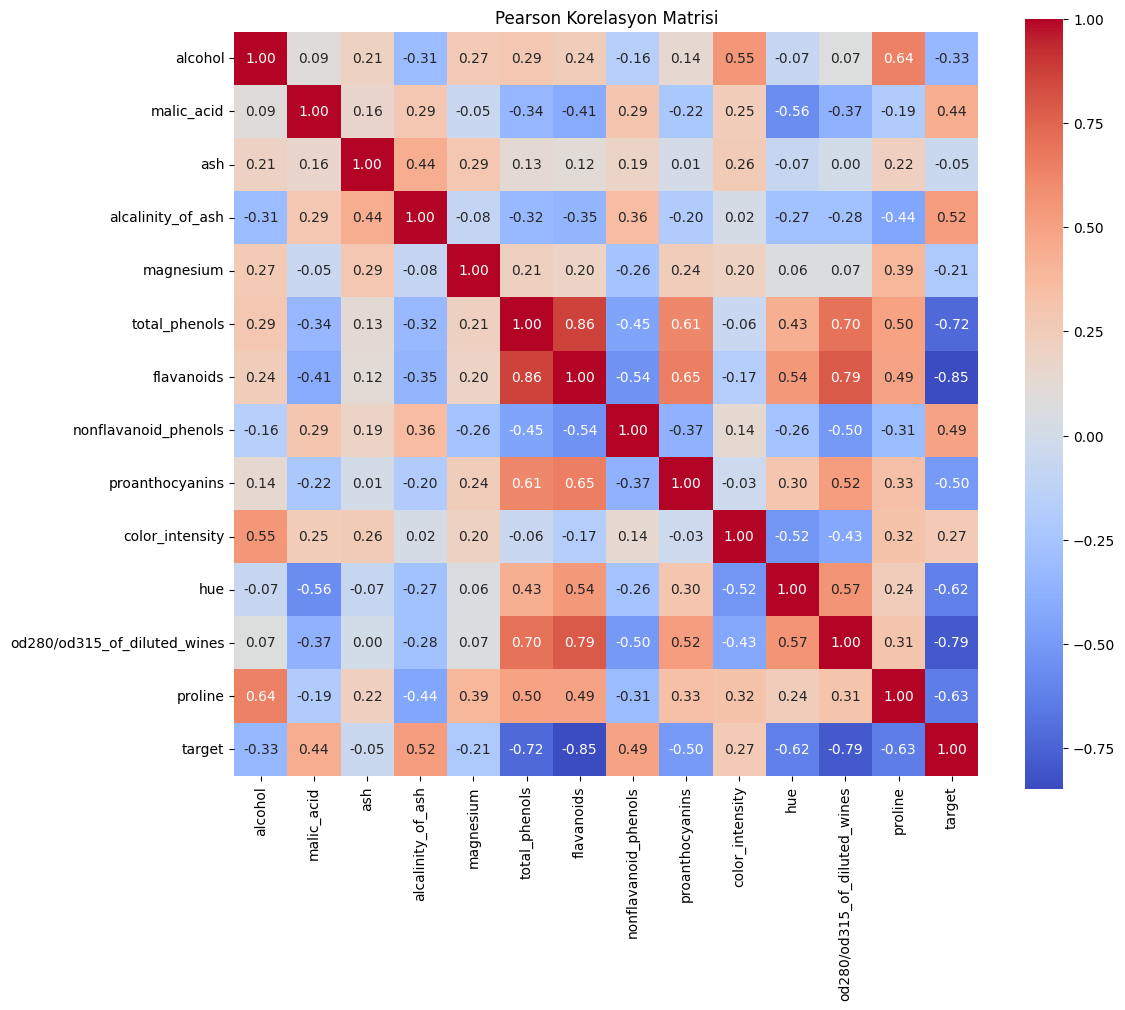

In [160]:
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Pearson Korelasyon Matrisi")
plt.show()

In [161]:
#  En yüksek korelasyonlu 3 çift
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top_corrs = upper_tri.stack().sort_values(ascending=False).head(3)
print("\nEn Yüksek Pozitif Korelasyonlu 3 Çift:\n", top_corrs)


En Yüksek Pozitif Korelasyonlu 3 Çift:
 total_phenols  flavanoids                      0.864564
flavanoids     od280/od315_of_diluted_wines    0.787194
total_phenols  od280/od315_of_diluted_wines    0.699949
dtype: float64


Yorum:

total_phenols + flavanoids: Bu iki özellik arasındaki çok güçlü pozitif korelasyon beklenen bir durumdur çünkü flavanoidler, toplam fenollerin bir alt grubudur. Şaraptaki fenolik bileşikler tat, renk ve antioksidan özellikler açısından belirleyicidir.

flavanoids + od280/od315_of_diluted_wines: OD280/OD315 oranı, şaraptaki protein içeriğini ölçen spektroskopik bir parametredir. Flavanoidlerle güçlü ilişkisi, bu bileşiklerin şarabın kimyasal yapısını birlikte etkilediğini gösterir.

total_phenols + od280/od315_of_diluted_wines: Fenolik bileşiklerin spektroskopik ölçümlerle tutarlı şekilde değişmesi, bu parametrelerin şarap kalitesinin güvenilir göstergeleri olduğunu ortaya koyar.

#### 3.3 Boxplot Analizi

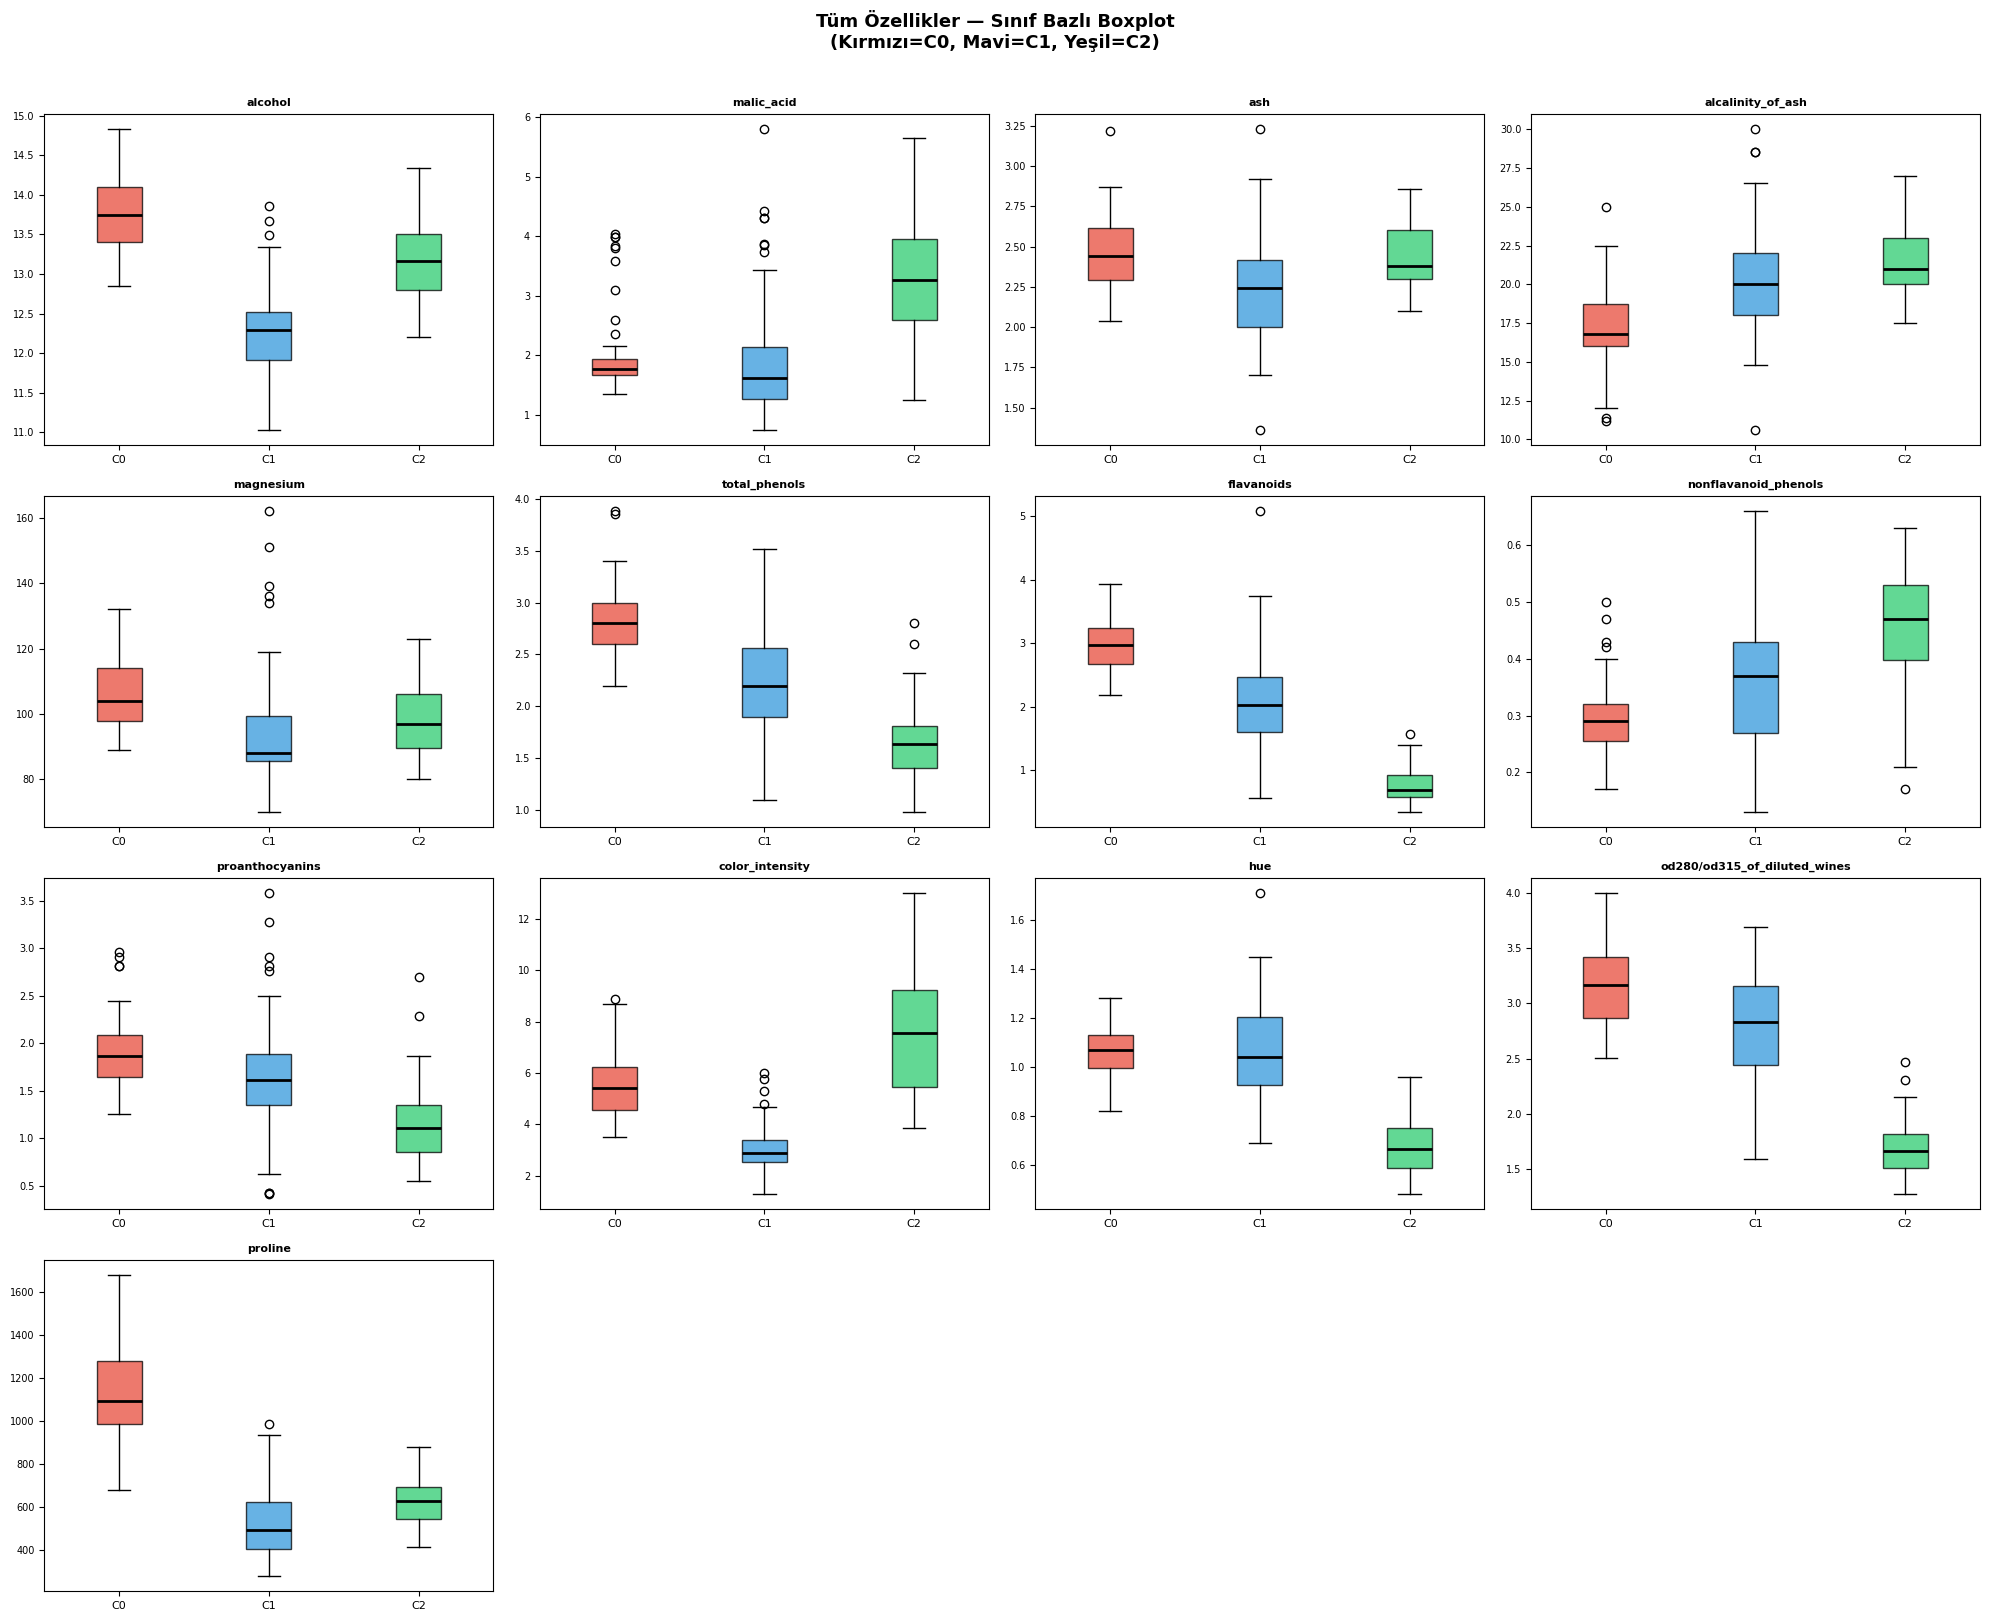

In [162]:
features = X.columns.tolist()
ncols = 4
nrows = int(np.ceil(len(features) / ncols))

palette_3 = {0: '#E74C3C', 1: '#3498DB', 2: '#2ECC71'}
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))

for ax, feat in zip(axes.flat, features):
    data_cls = [X.loc[y == c, feat].values for c in [0, 1, 2]]
    bp = ax.boxplot(data_cls, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], palette_3.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticklabels(['C0', 'C1', 'C2'], fontsize=8)
    ax.set_title(feat, fontsize=8, fontweight='bold')
    ax.tick_params(axis='y', labelsize=7)

for ax in axes.flat[len(features):]:
    ax.set_visible(False)

plt.suptitle('Tüm Özellikler — Sınıf Bazlı Boxplot\n(Kırmızı=C0, Mavi=C1, Yeşil=C2)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Yorum:

• alcohol ve proline özelliklerinde Class_0 diğer sınıflara kıyasla belirgin biçimde yüksek değerler sergilemektedir.

• flavanoids ve od280/od315 özelliklerinde Class_0 net biçimde ayrışmaktadır.

• Üç sınıf arasında orta düzeyde örtüşme gözlemlenen özellikler bulunmaktadır. bu özellikler tek başına güçlü ayırt edici değildir.

• Aykırı değerler özellikle proline ve magnesium özelliklerinde yoğunlaşmaktadır

### 4. Veri Setinin Bölünmesi

In [163]:
# 1: %20 test
X_trainval, X_test_raw, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# 2: train+val'ın %12,5'i = kalan veri setinin %10'u → validation
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.125,
    random_state=RANDOM_STATE,
    stratify=y_trainval
)

total = X_train_raw.shape[0] + X_val_raw.shape[0] + X_test_raw.shape[0]
print('=== Veri Bölme Özeti ===')
print(f'Eğitim (Train)      : {X_train_raw.shape[0]:>4} örnek  ({X_train_raw.shape[0]/len(X)*100:.1f}%)')
print(f'Doğrulama (Val)     : {X_val_raw.shape[0]:>4} örnek  ({X_val_raw.shape[0]/len(X)*100:.1f}%)')
print(f'Test                : {X_test_raw.shape[0]:>4} örnek  ({X_test_raw.shape[0]/len(X)*100:.1f}%)')
print(f'Toplam              : {total:>4} örnek')

print('\nSınıf dağılımları (stratify doğrulaması):')
for split_name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    counts = y_split.value_counts().sort_index()
    print(f'  {split_name:5s}: {dict(counts)}')

=== Veri Bölme Özeti ===
Eğitim (Train)      :  124 örnek  (69.7%)
Doğrulama (Val)     :   18 örnek  (10.1%)
Test                :   36 örnek  (20.2%)
Toplam              :  178 örnek

Sınıf dağılımları (stratify doğrulaması):
  Train: {0: np.int64(41), 1: np.int64(50), 2: np.int64(33)}
  Val  : {0: np.int64(6), 1: np.int64(7), 2: np.int64(5)}
  Test : {0: np.int64(12), 1: np.int64(14), 2: np.int64(10)}


### 5. Veri Ölçeklendirme (Scaling)

In [164]:
scaler = RobustScaler()

# Fit: YALNIZCA train seti üzerinde
X_train = pd.DataFrame(
    scaler.fit_transform(X_train_raw),
    columns=X.columns,
    index=X_train_raw.index
)

# Transform: val ve test setlerine uygulanır (fit yapılmaz)
X_val = pd.DataFrame(
    scaler.transform(X_val_raw),
    columns=X.columns,
    index=X_val_raw.index
)

X_test = pd.DataFrame(
    scaler.transform(X_test_raw),
    columns=X.columns,
    index=X_test_raw.index
)

# Referans için tam ölçekli veri (SHAP / PCA fit için)
X_scaled = pd.DataFrame(
    scaler.transform(X),
    columns=X.columns
)

print('=== Ölçekleme Sonrası Train İstatistikleri ===')
pd.DataFrame({
    'Median'  : X_train.median().round(5),   # RobustScaler: merkez medyan, ortalama/std değil.
    'IQR'     : (X_train.quantile(0.75) - X_train.quantile(0.25)).round(4),
    'Min'     : X_train.min().round(3),
    'Max'     : X_train.max().round(3)
}).head(8)

=== Ölçekleme Sonrası Train İstatistikleri ===


,Median,IQR,Min,Max
alcohol,-0.0,1.0,-1.628,1.552
malic_acid,-0.0,1.0,-0.698,2.430
ash,0.0,1.0,-2.764,2.403
alcalinity_of_ash,0.0,1.0,-2.058,2.428
magnesium,0.0,1.0,-0.950,3.250
total_phenols,0.0,1.0,-1.119,1.541
flavanoids,0.0,1.0,-1.080,1.055
nonflavanoid_phenols,0.0,1.0,-1.313,1.813


In [165]:
print('✅ Ölçekleme tamamlandı.')
print(f'   X_train shape : {X_train.shape}')
print(f'   X_val   shape : {X_val.shape}')
print(f'   X_test  shape : {X_test.shape}')
print('   Scaler fit → SADECE train üzerinde (leakage yok)')

✅ Ölçekleme tamamlandı.
   X_train shape : (124, 13)
   X_val   shape : (18, 13)
   X_test  shape : (36, 13)
   Scaler fit → SADECE train üzerinde (leakage yok)


### 6. Özellik Seçimi ve Boyut İndirgeme

#### 6.1 PCA (Principal Component Analysis)

Ortalama explained variance eşiği : 0.0769
Seçilen bileşen sayısı (≥ ort.)  : 4
Seçilen bileşenlerin toplam exp. varyansı: 0.7369


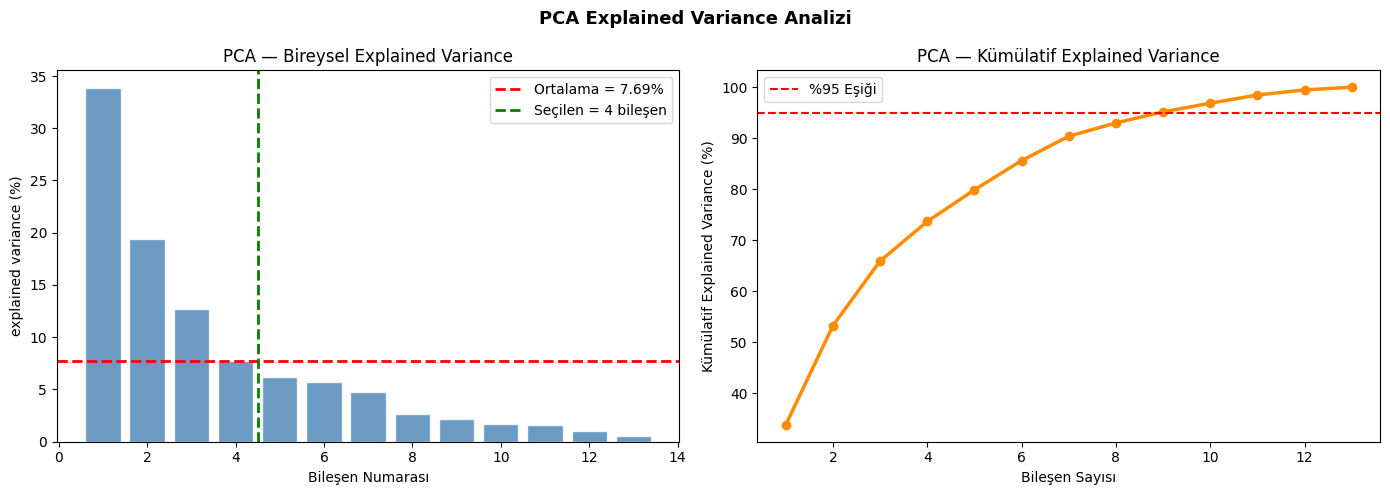


 Yorum: Ortalama varyans eşiği (7.69%) üzerinde 4 bileşen seçilmiştir.


In [166]:
# Tüm bileşenlerle PCA — explained variance oranını incele
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train)

exp_var = pca_full.explained_variance_ratio_
mean_var = exp_var.mean()
n_pca = int(np.sum(exp_var >= mean_var))

print(f'Ortalama explained variance eşiği : {mean_var:.4f}')
print(f'Seçilen bileşen sayısı (≥ ort.)  : {n_pca}')
print(f'Seçilen bileşenlerin toplam exp. varyansı: {exp_var[:n_pca].sum():.4f}')

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bireysel varyans
axes[0].bar(range(1, len(exp_var)+1), exp_var * 100,
            color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axhline(mean_var * 100, color='red', linewidth=2, linestyle='--',
                label=f'Ortalama = {mean_var*100:.2f}%')
axes[0].axvline(n_pca + 0.5, color='green', linewidth=2, linestyle='--',
                label=f'Seçilen = {n_pca} bileşen')
axes[0].set_xlabel('Bileşen Numarası')
axes[0].set_ylabel('explained variance (%)')
axes[0].set_title('PCA — Bireysel Explained Variance')
axes[0].legend()

# Kümülatif varyans
axes[1].plot(range(1, len(exp_var)+1), np.cumsum(exp_var)*100,
             'o-', color='darkorange', linewidth=2.5, markersize=6)
axes[1].axhline(95, color='red', linestyle='--', label='%95 Eşiği')
axes[1].set_xlabel('Bileşen Sayısı')
axes[1].set_ylabel('Kümülatif Explained Variance (%)')
axes[1].set_title('PCA — Kümülatif Explained Variance')
axes[1].legend()

plt.suptitle('PCA Explained Variance Analizi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n Yorum: Ortalama varyans eşiği ({mean_var*100:.2f}%) üzerinde {n_pca} bileşen seçilmiştir.')

PCA dönüşümü tamamlandı. Shape: (124, 4)


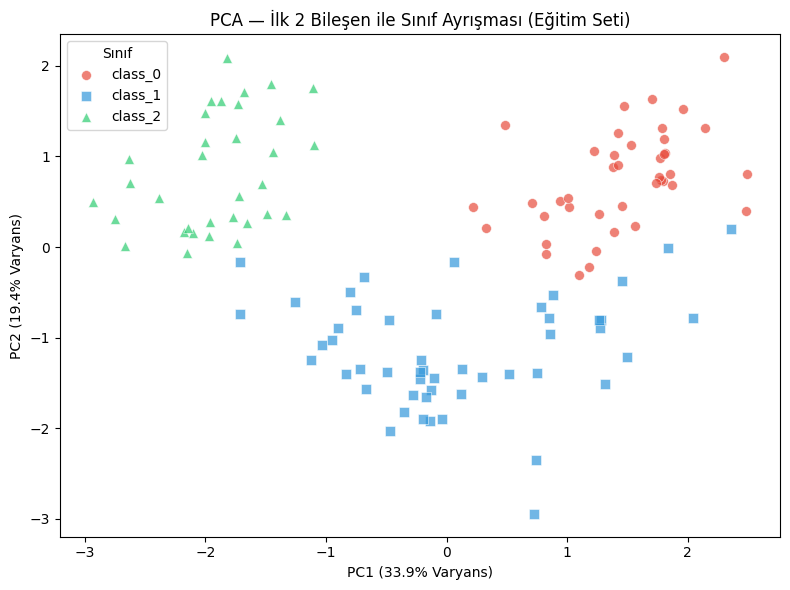

In [167]:
# PCA dönüşümü — seçilen n_pca bileşenle
pca = PCA(n_components=n_pca, random_state=RANDOM_STATE)
pca_cols = [f'PC{i+1}' for i in range(n_pca)]

X_train_pca = pd.DataFrame(pca.fit_transform(X_train), columns=pca_cols, index=X_train.index)
X_val_pca   = pd.DataFrame(pca.transform(X_val),       columns=pca_cols, index=X_val.index)
X_test_pca  = pd.DataFrame(pca.transform(X_test),      columns=pca_cols, index=X_test.index)

print(f'PCA dönüşümü tamamlandı. Shape: {X_train_pca.shape}')

# 2D scatter: PC1 & PC2
colors  = {0: '#E74C3C', 1: '#3498DB', 2: '#2ECC71'}
markers = {0: 'o', 1: 's', 2: '^'}

fig, ax = plt.subplots(figsize=(8, 6))
for cls in [0, 1, 2]:
    mask = y_train.values == cls
    ax.scatter(
        X_train_pca.loc[mask, 'PC1'],
        X_train_pca.loc[mask, 'PC2'],
        c=colors[cls], marker=markers[cls],
        label=class_names[cls], alpha=0.7, s=50, edgecolors='white', linewidth=0.5
    )
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Varyans)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Varyans)')
ax.set_title('PCA — İlk 2 Bileşen ile Sınıf Ayrışması (Eğitim Seti)')
ax.legend(title='Sınıf')
plt.tight_layout()
plt.show()



#### 6.2 LDA (Linear Discriminant Analysis)

LDA dönüşümü tamamlandı.
Explained Variance Oranları: LD1=0.6934, LD2=0.3066


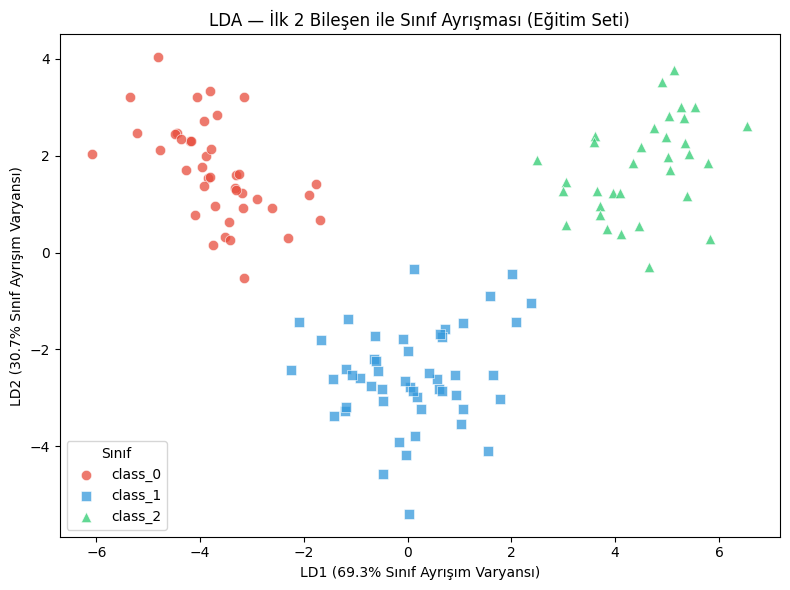

In [168]:
lda = LinearDiscriminantAnalysis(n_components=2)
lda_cols = ['LD1', 'LD2']

X_train_lda = pd.DataFrame(lda.fit_transform(X_train, y_train), columns=lda_cols, index=X_train.index)
X_val_lda   = pd.DataFrame(lda.transform(X_val),                columns=lda_cols, index=X_val.index)
X_test_lda  = pd.DataFrame(lda.transform(X_test),               columns=lda_cols, index=X_test.index)

print('LDA dönüşümü tamamlandı.')
print(f'Explained Variance Oranları: LD1={lda.explained_variance_ratio_[0]:.4f}, LD2={lda.explained_variance_ratio_[1]:.4f}')

# 2D Scatter: LD1 & LD2
fig, ax = plt.subplots(figsize=(8, 6))
for cls in [0, 1, 2]:
    mask = y_train.values == cls
    ax.scatter(
        X_train_lda.loc[mask, 'LD1'],
        X_train_lda.loc[mask, 'LD2'],
        c=colors[cls], marker=markers[cls],
        label=class_names[cls], alpha=0.75, s=55, edgecolors='white', linewidth=0.5
    )
ax.set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]*100:.1f}% Sınıf Ayrışım Varyansı)')
ax.set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]*100:.1f}% Sınıf Ayrışım Varyansı)')
ax.set_title('LDA — İlk 2 Bileşen ile Sınıf Ayrışması (Eğitim Seti)')
ax.legend(title='Sınıf')
plt.tight_layout()
plt.show()


Yorum:
LDA, PCA'ya kıyasla çok daha belirgin bir sınıf ayrışması sağlamıştır.

Üç sınıf iki boyutlu grafikte birbirinden uzak bölgelere konumlanmış olup sınır örtüşmesi oldukça azdır.

LDA'nın PCA'ya göre sınıflandırma problemleri için daha uygun bir boyut indirgeme yöntemi olduğunu görülmektedir.

In [169]:
# 1. Ham (Preprocessed) — 13 özellik, RobustScaler uygulanmış
repr_preprocessed = (X_train, X_val, X_test)

# 2. PCA ile indirgenmiş — n_pca bileşen
repr_pca = (X_train_pca, X_val_pca, X_test_pca)

# 3. LDA ile indirgenmiş — 2 bileşen
repr_lda = (X_train_lda, X_val_lda, X_test_lda)

print(f'Preprocessed : {X_train.shape[1]} özellik')
print(f'PCA          : {X_train_pca.shape[1]} bileşen')
print(f'LDA          : {X_train_lda.shape[1]} bileşen')

Preprocessed : 13 özellik
PCA          : 4 bileşen
LDA          : 2 bileşen


### 7. Makine Öğrenmesi Modellerinin Kurulması

In [170]:
# Model tanımları
model_defs = {
    'LogisticRegression' : LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'DecisionTree'       : DecisionTreeClassifier(random_state=RANDOM_STATE),
    'RandomForest'       : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost'            : XGBClassifier(n_estimators=100, random_state=RANDOM_STATE,
                                         eval_metric='mlogloss', verbosity=0,
                                         num_class=3, use_label_encoder=False),
    'GaussianNB'         : GaussianNB()
}

# Veri temsilleri
reprs = {
    'Preprocessed' : repr_preprocessed,
    'PCA'          : repr_pca,
    'LDA'          : repr_lda
}

# Eğitim
trained = {}
for repr_name, (Xtr, Xv, Xte) in reprs.items():
    for mname, mtemplate in model_defs.items():
        m = copy.deepcopy(mtemplate)
        m.fit(Xtr, y_train)
        trained[(repr_name, mname)] = m
        print(f'✅  {repr_name:15s} | {mname}')

print(f'\n🎯 Toplam {len(trained)} model eğitildi.')

✅  Preprocessed    | LogisticRegression
✅  Preprocessed    | DecisionTree
✅  Preprocessed    | RandomForest
✅  Preprocessed    | XGBoost
✅  Preprocessed    | GaussianNB
✅  PCA             | LogisticRegression
✅  PCA             | DecisionTree
✅  PCA             | RandomForest
✅  PCA             | XGBoost
✅  PCA             | GaussianNB
✅  LDA             | LogisticRegression
✅  LDA             | DecisionTree
✅  LDA             | RandomForest
✅  LDA             | XGBoost
✅  LDA             | GaussianNB

🎯 Toplam 15 model eğitildi.


### 8. Validation Performanslarının Ölçülmesi

In [171]:
def eval_multiclass(model, Xeval, yeval):
    """Çok sınıflı metrik hesaplama."""
    yp   = model.predict(Xeval)
    yprob = model.predict_proba(Xeval)
    return {
        'Accuracy'  : round(accuracy_score(yeval, yp), 4),
        'Precision' : round(precision_score(yeval, yp, average='weighted', zero_division=0), 4),
        'Recall'    : round(recall_score(yeval, yp, average='weighted', zero_division=0), 4),
        'F1-Score'  : round(f1_score(yeval, yp, average='weighted', zero_division=0), 4),
        'ROC-AUC'   : round(roc_auc_score(yeval, yprob, multi_class='ovr', average='weighted'), 4)
    }

val_results = []
for (repr_name, mname), model in trained.items():
    _, Xv, _ = reprs[repr_name]
    metrics = eval_multiclass(model, Xv, y_val)
    val_results.append({'Temsil': repr_name, 'Model': mname, **metrics})

val_df = (pd.DataFrame(val_results)
          .sort_values('F1-Score', ascending=False)
          .reset_index(drop=True))

print('=== Validation Seti Karşılaştırma Tablosu ===')
display(val_df)

=== Validation Seti Karşılaştırma Tablosu ===


,Temsil,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Preprocessed,LogisticRegression,1.0000,1.0000,1.0000,1.0000,1.0000
1,Preprocessed,RandomForest,1.0000,1.0000,1.0000,1.0000,1.0000
2,Preprocessed,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000
3,PCA,LogisticRegression,1.0000,1.0000,1.0000,1.0000,1.0000
4,Preprocessed,GaussianNB,1.0000,1.0000,1.0000,1.0000,1.0000
5,PCA,GaussianNB,1.0000,1.0000,1.0000,1.0000,1.0000
6,LDA,LogisticRegression,1.0000,1.0000,1.0000,1.0000,1.0000
7,LDA,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000
8,LDA,GaussianNB,1.0000,1.0000,1.0000,1.0000,1.0000
9,LDA,RandomForest,1.0000,1.0000,1.0000,1.0000,1.0000


In [175]:
# En iyi modeli belirle
best_row   = val_df.iloc[0]
best_repr  = best_row['Temsil']
best_mname = best_row['Model']
best_model = trained[(best_repr, best_mname)]

print('=' * 55)
print(f'   En İyi Model     : {best_mname}')
print(f'   Özellik Temsili  : {best_repr}')
print(f'   Val F1-Score     : {best_row["F1-Score"]}')
print(f'   Val ROC-AUC      : {best_row["ROC-AUC"]}')
print('=' * 55)

   En İyi Model     : LogisticRegression
   Özellik Temsili  : Preprocessed
   Val F1-Score     : 1.0
   Val ROC-AUC      : 1.0


### 9. En İyi Modelin Test Üzerinde Değerlendirilmesi

### 9.1 Performans Metrikleri

In [176]:
_, _, X_test_best = reprs[best_repr]

y_pred_test = best_model.predict(X_test_best)
y_prob_test = best_model.predict_proba(X_test_best)

test_metrics = {
    'Accuracy'  : accuracy_score(y_test, y_pred_test),
    'Precision' : precision_score(y_test, y_pred_test, average='weighted', zero_division=0),
    'Recall'    : recall_score(y_test, y_pred_test, average='weighted', zero_division=0),
    'F1-Score'  : f1_score(y_test, y_pred_test, average='weighted', zero_division=0),
    'ROC-AUC'   : roc_auc_score(y_test, y_prob_test, multi_class='ovr', average='weighted')
}

print(f'=== Test Seti Sonuçları: {best_mname} ({best_repr}) ===')
for k, v in test_metrics.items():
    print(f'  {k:12s}: {v:.4f}')

=== Test Seti Sonuçları: LogisticRegression (Preprocessed) ===
  Accuracy    : 0.9722
  Precision   : 0.9741
  Recall      : 0.9722
  F1-Score    : 0.9720
  ROC-AUC     : 1.0000


### 9.2 Confusion Matrix

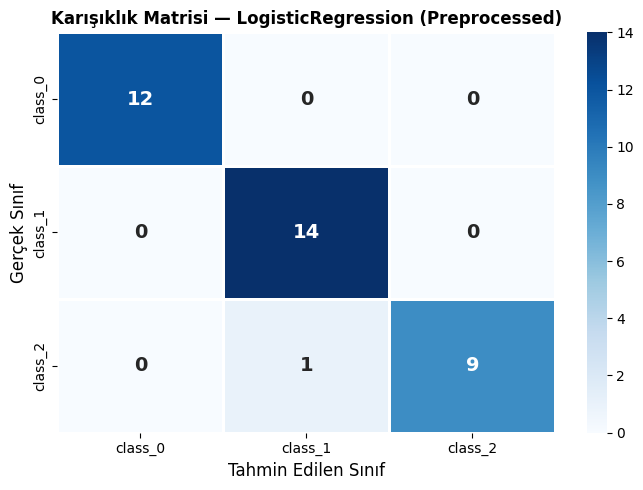

{36}


In [177]:
cm = confusion_matrix(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=1, linecolor='white',
    annot_kws={'size': 14, 'weight': 'bold'}
)
ax.set_xlabel('Tahmin Edilen Sınıf', fontsize=12)
ax.set_ylabel('Gerçek Sınıf', fontsize=12)
ax.set_title(f'Confusion Matrix — {best_mname} ({best_repr})', fontweight='bold')
plt.tight_layout()
plt.show()

print({X_test_best.shape[0]})

Yorum:
Model 36 örnekten 35'ini doğru sınıflandırmış, yalnızca 1 hata yapmıştır. class_0 ve class_1 mükemmel hassasiyetle ayrıştırılmıştır. Tek hata class_2 ile class_1 arasında gerçekleşmiş olup bu iki sınıfın kimyasal özellikleri açısından diğerlerine kıyasla daha yakın olduğuna işaret etmektedir.

### 9.3 ROC Eğrisi

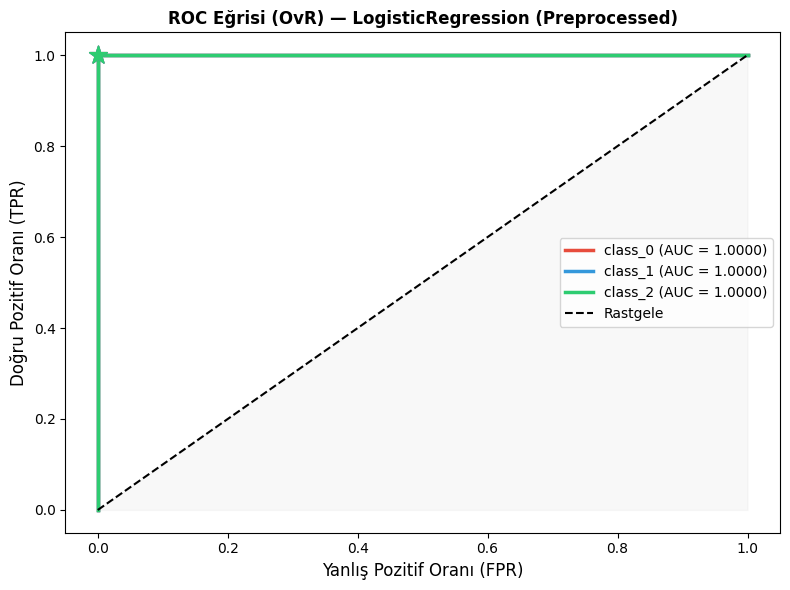

In [178]:
# Çok sınıflı ROC: her sınıf için OvR
n_classes  = 3
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

roc_colors = ['#E74C3C', '#3498DB', '#2ECC71']

fig, ax = plt.subplots(figsize=(8, 6))

for cls_idx in range(n_classes):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, cls_idx], y_prob_test[:, cls_idx])
    auc_val = roc_auc_score(y_test_bin[:, cls_idx], y_prob_test[:, cls_idx])

    ax.plot(fpr, tpr, color=roc_colors[cls_idx], linewidth=2.5,
            label=f'{class_names[cls_idx]} (AUC = {auc_val:.4f})')

    # Youden J optimum eşik
    j_idx = np.argmax(tpr - fpr)
    ax.scatter(fpr[j_idx], tpr[j_idx], color=roc_colors[cls_idx],
               marker='*', s=180, zorder=5)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Rastgele')
ax.set_xlabel('Yanlış Pozitif Oranı (FPR)', fontsize=12)
ax.set_ylabel('Doğru Pozitif Oranı (TPR)', fontsize=12)
ax.set_title(f'ROC Eğrisi (OvR) — {best_mname} ({best_repr})', fontweight='bold')
ax.legend(fontsize=10)
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
plt.tight_layout()
plt.show()

Her sınıf için OvR (One-vs-Rest) stratejisiyle ayrı eğri çizilmiştir.
Ancak üç eğri de üst üste çakıştığından grafikte yalnızca yeşil
(class_2) eğrisi görünmektedir.

AUC Sonuçları:
- class_0: AUC = 1.0000
- class_1: AUC = 1.0000
- class_2: AUC = 1.0000

J = Sensitivity - (1 - Specificity)

Varsayılan eşik 0.5'tir. Eşiği düşürürsek,

  → Sensitivity artar → daha fazla pozitif yakalanır
  
  → Precision düşebilir → yanlış alarm sayısı artar

### 10. XAI — SHAP Açıklanabilirlik Analizi

#### 10.1 En İyi Validation Modeli için SHAP Analizi

In [179]:
print(f'SHAP açıklayıcısı: {best_mname} — {best_repr}')

_, _, Xte_best = reprs[best_repr]

tree_models = ['RandomForest', 'DecisionTree', 'XGBoost']

if best_mname in tree_models:
    explainer_best = shap.TreeExplainer(best_model)
    shap_vals_best = explainer_best.shap_values(Xte_best)
    # RandomForest/DecisionTree
    # XGBoost multiclass: shape (n, features, n_classes) veya liste
    if isinstance(shap_vals_best, list):
        # Her sınıf için ayrı array; sınıf ortalaması için stack
        shap_for_plot = np.array(shap_vals_best)  # (3, n, features)
        shap_mean_abs = np.abs(shap_for_plot).mean(axis=(0, 1))  # (features,)
        shap_plot_arr = shap_vals_best  # summary_plot listeyi kabul eder
    else:
        # XGBoost: (n, features, classes)
        shap_for_plot = shap_vals_best
        shap_mean_abs = np.abs(shap_vals_best).mean(axis=(0, 2))
        shap_plot_arr = shap_vals_best[:, :, 0]  # class_0 için
else:
    bg = shap.sample(Xte_best, min(30, len(Xte_best)))
    explainer_best = shap.KernelExplainer(best_model.predict_proba, bg)
    n_sample = min(80, len(Xte_best))
    shap_vals_best = explainer_best.shap_values(Xte_best.iloc[:n_sample])
    shap_plot_arr  = shap_vals_best
    Xte_best       = Xte_best.iloc[:n_sample]

print('✅ SHAP değerleri hesaplandı.')

SHAP açıklayıcısı: LogisticRegression — Preprocessed


  0%|          | 0/36 [00:00<?, ?it/s]

✅ SHAP değerleri hesaplandı.


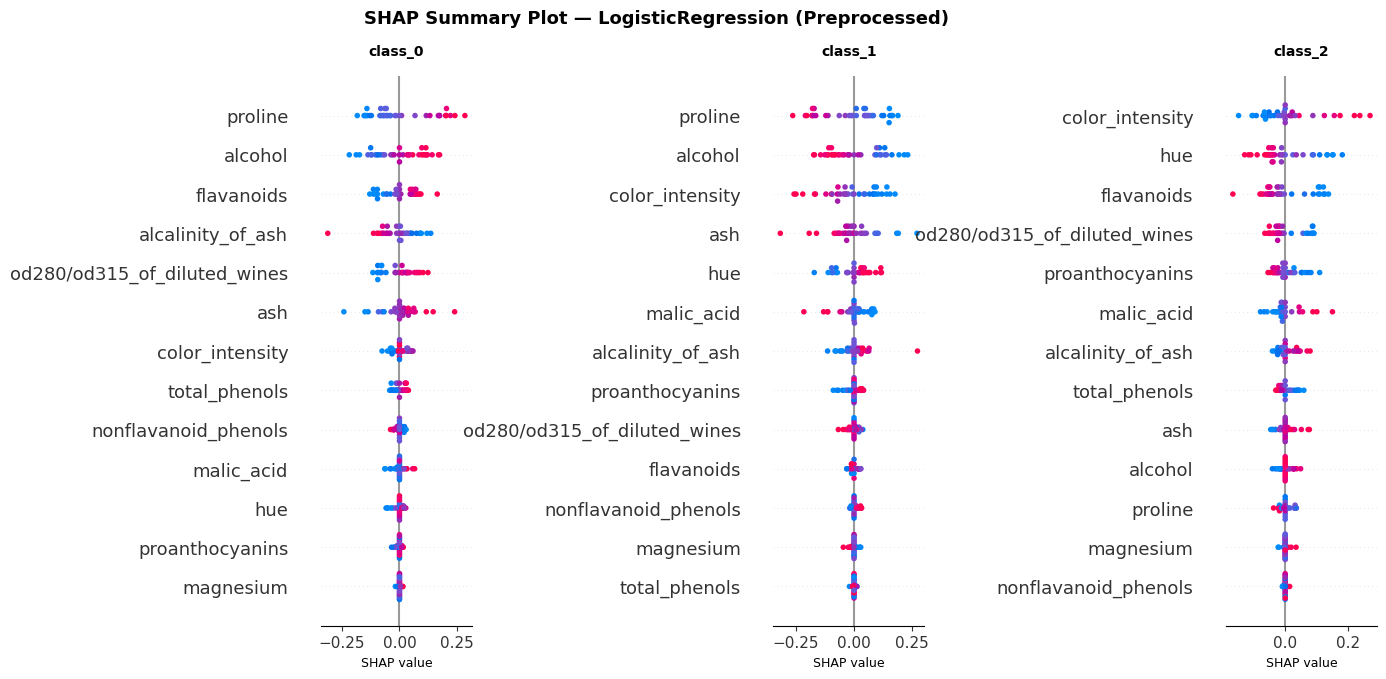

In [205]:
plt.close('all')

fig, axes = plt.subplots(1, 3, figsize=(40, 9))
class_labels = ['class_0', 'class_1', 'class_2']

for i in range(3):
    plt.sca(axes[i])
    sv = shap_vals_best[i] if isinstance(shap_vals_best, list) else shap_vals_best[:, :, i]
    shap.summary_plot(
        sv,
        Xte_best,
        plot_type='dot',
        max_display=13,
        show=False,
        color_bar=False
    )
    axes[i].set_title(class_labels[i], fontweight='bold', fontsize=10, pad=15)
    axes[i].set_xlabel('SHAP value', fontsize=9)

plt.suptitle(f'SHAP Summary Plot — {best_mname} ({best_repr})',
             fontsize=13, fontweight='bold', y=1.02)
plt.subplots_adjust(wspace=2.0, left=0.08, right=1.4, top=0.92, bottom=0.1)
plt.show()


SHAP Summary:

Özelliğin orijinal değerine göre kırmızı-yüksek ve mazi-düşük renk alır.

Üstteki özellikler modelin kararı üzerinde en büyük etkiye sahip olanlardır.

Her sınıfın farklı özellikler tarafından tanımlandığı görülmektedir:
- class_0 → proline + alcohol (yüksek değerler)
- class_1 → proline + alcohol (düşük değerler) + color_intensity
- class_2 → color_intensity + hue + flavanoids

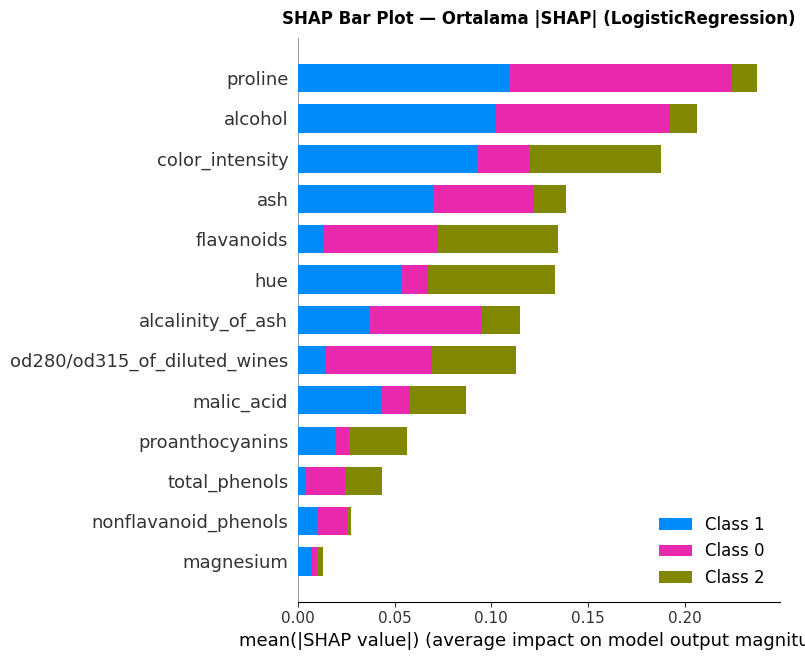

In [185]:
# SHAP Bar Plot
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_plot_arr,
    Xte_best,
    plot_type='bar',
    show=False,
    max_display=13
)
plt.title(f'SHAP Bar Plot — Ortalama |SHAP| ({best_mname})',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

1. proline       (~0.23) — En belirleyici özellik. Her üç sınıf için
                           de yüksek katkı sağlamaktadır.
2. alcohol       (~0.21) — İkinci en önemli özellik. Class_1 ve
                           Class_0 ayrımında öne çıkmaktadır.
3. color_intensity (~0.19) — Class_2 için belirgin katkı sunarken
                           diğer sınıflara da orta etki yapar.
4. ash           (~0.14) — Class_0 ve Class_1 ayrımında aktif rol oynar.
5. flavanoids    (~0.13) — Korelasyon analizinde de öne çıkan bu
                           özellik SHAP'ta da üst sırada yer almaktadır.

### 10.2 PCA ve LDA Temsilleri için SHAP Karşılaştırması

In [206]:
# PCA temsili için en iyi model
pca_best_row   = val_df[val_df['Temsil'] == 'PCA'].iloc[0]
pca_best_name  = pca_best_row['Model']
pca_model      = trained[('PCA', pca_best_name)]

lda_best_row   = val_df[val_df['Temsil'] == 'LDA'].iloc[0]
lda_best_name  = lda_best_row['Model']
lda_model      = trained[('LDA', lda_best_name)]

print(f'PCA modeli: {pca_best_name} (Val F1={pca_best_row["F1-Score"]})')
print(f'LDA modeli: {lda_best_name} (Val F1={lda_best_row["F1-Score"]})')

def get_shap_arr(model, mname, X_data, tree_models=tree_models):
    """Modele uygun SHAP değerlerini döndürür."""
    if mname in tree_models:
        exp = shap.TreeExplainer(model)
        sv  = exp.shap_values(X_data)
        if isinstance(sv, list):
            return sv  # liste olarak döner
        return sv
    else:
        bg  = shap.sample(X_data, min(30, len(X_data)))
        exp = shap.KernelExplainer(model.predict_proba, bg)
        n   = min(60, len(X_data))
        sv  = exp.shap_values(X_data.iloc[:n])
        return sv

print('\nPCA SHAP hesaplanıyor...')
sv_pca = get_shap_arr(pca_model, pca_best_name, X_test_pca)
Xpca_shap = X_test_pca if pca_best_name in tree_models else X_test_pca.iloc[:60]

print('LDA SHAP hesaplanıyor...')
sv_lda = get_shap_arr(lda_model, lda_best_name, X_test_lda)
Xlda_shap = X_test_lda if lda_best_name in tree_models else X_test_lda.iloc[:60]

print('✅ Tamamlandı.')

PCA modeli: LogisticRegression (Val F1=1.0)
LDA modeli: LogisticRegression (Val F1=1.0)

PCA SHAP hesaplanıyor...


  0%|          | 0/36 [00:00<?, ?it/s]

LDA SHAP hesaplanıyor...


  0%|          | 0/36 [00:00<?, ?it/s]

✅ Tamamlandı.


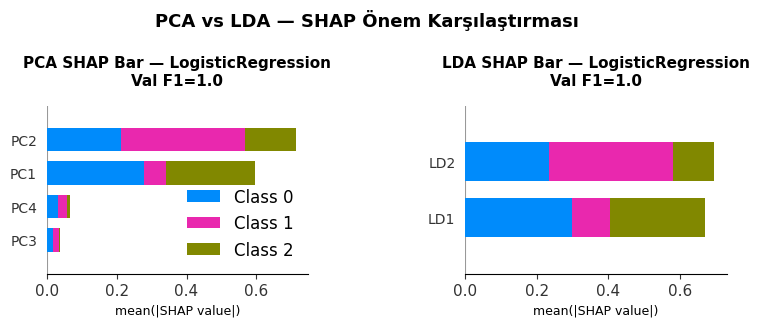

In [217]:
plt.close('all')

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

plt.sca(axes[0])
shap.summary_plot(sv_pca, Xpca_shap, plot_type='bar', show=False,
                  max_display=n_pca, color_bar=False)
axes[0].set_title(f'PCA SHAP Bar — {pca_best_name}\nVal F1={pca_best_row["F1-Score"]}',
                  fontweight='bold', fontsize=11, pad=15)
axes[0].set_xlabel('mean(|SHAP value|)', fontsize=9)
axes[0].tick_params(axis='y', labelsize=10)

plt.sca(axes[1])
shap.summary_plot(sv_lda, Xlda_shap, plot_type='bar', show=False,
                  max_display=2, color_bar=False)
axes[1].set_title(f'LDA SHAP Bar — {lda_best_name}\nVal F1={lda_best_row["F1-Score"]}',
                  fontweight='bold', fontsize=11, pad=15)
axes[1].set_xlabel('mean(|SHAP value|)', fontsize=9)
axes[1].tick_params(axis='y', labelsize=10)
axes[1].legend_.remove()

plt.suptitle('PCA vs LDA — SHAP Önem Karşılaştırması',
             fontsize=13, fontweight='bold', y=1.3)

plt.subplots_adjust(wspace=0.6, left=0.1, right=0.95, top=0.88, bottom=0.15)
plt.show()

- PC2 en yüksek SHAP değerine sahiptir (~0.68).
  Her üç sınıf da PC2'den güçlü biçimde etkilenmektedir:
  - Class_0 ve Class_1 PC2'de baskın katkı gösterir.
  - Class_2 PC2'de orta düzey etkiye sahiptir.

- PC4 ve PC3 oldukça düşük SHAP değerlerine sahiptir (<0.08).
  Bu bileşenler modelin kararına neredeyse hiç katkıda bulunmamaktadır.

- Varyansı en çok açıklayan bileşenler (PC1, PC2) aynı
zamanda sınıflandırma için de en belirleyici bileşenler olmuştur.


- LDA bileşenlerinin sınıf ayrışımını doğrudan maksimize edecek şekilde tasarlanması nedeniyle LD1 ve LD2 birbirine yakın SHAP değerleri üretmiştir. Yalnızca 2 bileşenle PCA'nın 4 bileşeniyle elde ettiği SHAP değerlerine ulaşılması, LDA'nın sınıflandırma problemleri için daha verimli bir boyut
indirgeme yöntemi olduğunu ortaya koymaktadır.